# Modest data

## 0. Prerrequisites

In [1]:
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.fft import fft2, ifft2, fftshift

from astropy.io import fits
from astropy import units as u

plt.rcParams.update({
  'axes.titlesize': 'x-large',  # heading 1
  'axes.labelsize': 'large',   # heading 2
  'xtick.labelsize': 'medium',         # fontsize of the ticks
  'ytick.labelsize': 'medium',         # fontsize of the ticks
  'font.family': 'serif',        # Font family
  'text.usetex': False,          # Do not use LaTeX for text rendering
  'figure.figsize': (10, 8),     # Default figure size
  'savefig.dpi': 300,            # High resolution for saving figures
  'savefig.format': 'png',       # Default format for saving figures
  'legend.fontsize': 'small',  # Font size for legends
  'lines.linewidth': 2,          # Line width for plots
  'lines.markersize': 8,         # Marker size for plots,
  'axes.formatter.useoffset': False,  # Disable offset
  'axes.formatter.use_mathtext': True,  # Use scientific notation
  'axes.formatter.limits': (-3, 4),  # Use scientific notation for values over 10^2
  'axes.labelsize': 'large',     # Font size for axes labels
  'figure.titlesize': 'xx-large', # Font size for suptitles (heading 1)
  'axes.formatter.use_locale': False  # Do not use locale settings
})




## 1. Overview

This notebook documents how `ModestData` loads and prepares Hinode/SP MODEST products:
- Continuum image
- Observed Stokes (I, V)
- PSF-based Wiener deconvolution of Stokes
- Inverted profiles (I, V)
- SPINOR 2D inverted atmosphere
- Wavelength arrays for observed and inverted data
- Circular polarization masking applied consistently across products

## 2. Paths and Parameters
We define standard paths and Hinode/SP spectral parameters used across the steps.

In [ ]:


# Project-standard paths (adjust as needed)
modest_dir = Path("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/data/hinode-MODEST/INV_560_AR11967/")
psf_path = Path("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/data/hinode-MODEST/PSFs/hinode_psf_bin.0.16.fits")

# Hinode spectral parameters (observed)
NAXIS1 = 112
CRVAL1 = 6302.0
CDELT1 = 0.0215
CRPIX1 = 57
wl_obs = CRVAL1 + (np.arange(1, NAXIS1 + 1) - CRPIX1) * CDELT1
wl_obs = (wl_obs * u.Angstrom)

# Inverted spectral parameters (250 points spanning observed range)
NAXIS1_INV = 250
spectral_range = (wl_obs[-1] - wl_obs[0]).value
CDELT1_INV = spectral_range / (NAXIS1_INV - 1)
CRVAL1_INV = 6302.0
CRPIX1_INV = 125
wl_inv = CRVAL1_INV + (np.arange(1, NAXIS1_INV + 1) - CRPIX1_INV) * CDELT1_INV
wl_inv = (wl_inv * u.Angstrom)

# Masking threshold
circular_polarization_threshold = 1e-2

## 3. Load Observed and Continuum data
We read the continuum map (2D) from the FITS file.

### 3.1 Continuum loading

In [3]:
# Load continuum
with fits.open(modest_dir / "continuum.fits") as hdul:
    continuum = hdul[0].data    
print("continuum:", continuum.shape)

continuum: (390, 858)


Let's calculate from the continuum image the direction where the center of the disk should be located.

In [4]:
y_center_fov_arcsec = -126.0
x_center_fov_arcsec = 16.0
pixel_scale = 0.32
x_center_fov_pixel = continuum.shape[1] / 2
y_center_fov_pixel = continuum.shape[0] / 2
x_disk_offset_arcsec = 0 - x_center_fov_arcsec
y_disk_offset_arcsec = 0 - y_center_fov_arcsec
x_disk_offset_pixels = x_disk_offset_arcsec / pixel_scale
y_disk_offset_pixels = y_disk_offset_arcsec / pixel_scale
x_disk_center = x_center_fov_pixel + x_disk_offset_pixels
y_disk_center = y_center_fov_pixel + y_disk_offset_pixels
arrow_start_x = 800
arrow_start_y = 400
arrow_dx = x_disk_offset_pixels/10
arrow_dy = y_disk_offset_pixels/10

### 3.2 Observed Stokes loading

Let's charge now the observed stokes that include the Hinode SOT/SP noise and the wavelength sampling.

In [5]:
with fits.open(modest_dir / "inverted_obs.1.fits") as hdul:
    obs_cube_full = hdul[0].data   # (ny, nx, 4, nwl)
# Keep I (0) and V (1) as used in the pipeline

obs_stokes = {"I": obs_cube_full[:, :, 0, :],
              "V": obs_cube_full[:, :, 1, :]}

for key in obs_stokes.keys():
    print(f"obs_stokes {key}", obs_stokes[key].shape)

obs_stokes I (390, 858, 112)
obs_stokes V (390, 858, 112)


We will use them to calculate the circular polarization for generating a threshold under which the observed stokes should apply a mask over the scene such that regions with high magnetic fields are filtered according to our data availability.

In [6]:
# Load observed Stokes data for circular polarization analysis
# Calculate mean circular polarization (Stokes V) over wavelength
mean_circular_pol = np.mean(np.abs(obs_stokes["V"]), axis=2)

# Find pixels based on criteria
sample_pixels = {}

# 1. Highest continuum intensity
max_cont_idx = np.unravel_index(np.nanargmax(continuum), continuum.shape)
sample_pixels['max_continuum'] = {'y': max_cont_idx[0], 'x': max_cont_idx[1], 'label': 'Max Continuum'}

# 2. Lowest continuum intensity
min_cont_idx = np.unravel_index(np.nanargmin(continuum), continuum.shape)
sample_pixels['min_continuum'] = {'y': min_cont_idx[0], 'x': min_cont_idx[1], 'label': 'Min Continuum'}

# 3. Highest circular polarization
max_pol_idx = np.unravel_index(np.nanargmax(mean_circular_pol), mean_circular_pol.shape)
sample_pixels['max_polarization'] = {'y': max_pol_idx[0], 'x': max_pol_idx[1], 'label': 'Max |Stokes V|'}

# 4. Lowest circular polarization
min_pol_idx = np.unravel_index(np.nanargmin(mean_circular_pol), mean_circular_pol.shape)
sample_pixels['min_polarization'] = {'y': min_pol_idx[0], 'x': min_pol_idx[1], 'label': 'Min |Stokes V|'}

### 3.3 Scene plotting

In [7]:
def plot_modest_continuum(continuum: np.ndarray, sample_pixels: dict, x_center_fov_pixel: float, y_center_fov_pixel: float, 
                                    x_disk_center: float, y_disk_center: float, arrow_start_x: int, arrow_start_y: int, 
                                    arrow_dx: float, arrow_dy: float, modest_images_dir: str = None) -> None:
    """Plot MODEST continuum for the full scene with sample pixels marked and disk center arrow."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    im = ax.imshow(continuum, cmap='gray', origin='lower')
    ax.set_title("AR11967 - Full Scene Continuum")
    ax.set_xlabel('X [pixels]')
    ax.set_ylabel('Y [pixels]')
    
    # Plot FOV center
    ax.plot(x_center_fov_pixel, y_center_fov_pixel, 'b+', markersize=15, markeredgewidth=3, 
            label=f'FOV Center\n({16.0}, {-126.0})')
    
    # Plot disk center or arrow pointing to it
    if 0 <= x_disk_center <= continuum.shape[1] and 0 <= y_disk_center <= continuum.shape[0]:
        ax.plot(x_disk_center, y_disk_center, 'r+', markersize=15, markeredgewidth=3, 
                label='Solar Disk Center\n(0, 0)')
    else:
        ax.arrow(arrow_start_x, arrow_start_y, arrow_dx, arrow_dy, head_width=20, head_length=20, 
                fc='blue', ec='blue', linewidth=3, label='Solar Disk Center')
    
    # Plot all sample pixels with different colors/markers
    colors = ['red', 'blue', 'green', 'orange']
    markers = ['x', 'o', 's', '^']
    for i, (key, pixel_info) in enumerate(sample_pixels.items()):
        ax.plot(pixel_info['x'], pixel_info['y'], markers[i], color=colors[i], 
                markersize=8, markeredgewidth=2, label=pixel_info['label'])
    
    # Add text information
    textstr = f'AR11967\nFOV Center\n(16.0, -126.0)\nZürich: Fkc\nMagnetic: βγδ\nμ=0.99'
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8)
    ax.text(0.05, 0.05, textstr, transform=ax.transAxes, fontsize=11, 
            verticalalignment='bottom', bbox=props)
    
    ax.legend()
    
    # Add colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
    
    plt.tight_layout()
    if modest_images_dir:
        save_dir = Path(modest_images_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
    plt.show()
    plt.close(fig)

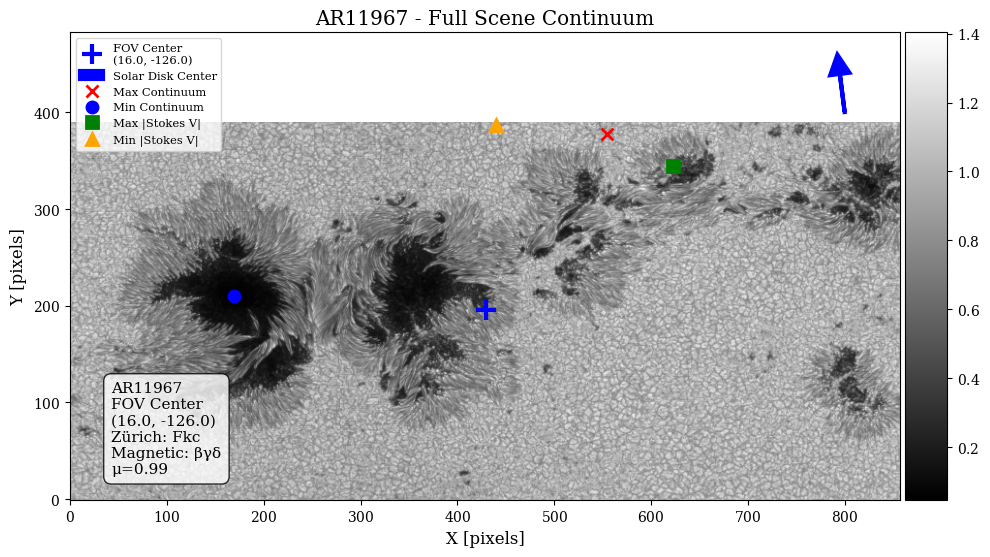

In [8]:
plot_modest_continuum(continuum, sample_pixels, x_center_fov_pixel, y_center_fov_pixel,
                                   x_disk_center, y_disk_center, arrow_start_x, arrow_start_y,
                                   arrow_dx, arrow_dy)

## 4. Deconvolution with PSF (Wiener) and smoothening

### 4.1 Understanding Hinode Observation Modes

Hinode/SOT-SP has two observation modes:
- **Normal mode**: 0.149" × 0.16" pixel scale (high spatial resolution)
- **Fast mode**: 0.297" × 0.32" pixel scale (faster scanning, lower resolution)

AR11967 was observed in **fast mode** with 0.32" pixels. The available PSF corresponds to 0.16" resolution. To apply this PSF correctly, we need to **upsample** the spatial dimensions by a factor of 2.

### 4.2 FFT-Based Upsampling with Noise Injection

The upsampling algorithm follows these steps:

1. **Pad the image** by mirroring to avoid edge artifacts
2. **FFT transform** and analyze power spectrum
3. **Estimate noise level** outside the diffraction limit
4. **Create noise field** at target resolution matching observed noise characteristics
5. **Replace center frequencies** with real data
6. **Inverse FFT** to obtain upsampled image

This approach preserves the signal characteristics within the diffraction limit while filling higher frequencies with appropriate noise.

#### 4.2.1 Theoretical Diffraction Limit

First, calculate the theoretical diffraction limit for Hinode:

In [9]:
# Hinode telescope parameters
aperture_m = 0.50*u.m  # meters
lambda_angstrom = 6302.0*u.AA  # Angstrom (Fe I line)
pixel_scale_arcsec = 0.32*u.arcsec  # Fast mode pixel scale

# Convert to SI units
lambda_m = lambda_angstrom.to(u.m)  # meters
scale_rad = pixel_scale_arcsec.to(u.rad).value  # radians/pixel

# Calculate diffraction limit
lambda_over_d = lambda_m / aperture_m  # radians
thdifflim_arcsec = lambda_over_d * np.degrees(1) * 3600  # arcseconds
q_number = lambda_over_d / scale_rad  # pixels

print(f"Theoretical diffraction limit: {thdifflim_arcsec:.3f} arcsec")
print(f"Diffraction limit in pixels (Q-number): {q_number:.2f}")
print(f"This means frequencies beyond ~{1/thdifflim_arcsec:.3f} cycles/arcsec are noise-dominated")

Theoretical diffraction limit: 0.260 arcsec
Diffraction limit in pixels (Q-number): 0.81
This means frequencies beyond ~3.847 cycles/arcsec are noise-dominated


#### 4.2.2 Create Elliptical Aperture Mask

Define a function to create an elliptical aperture mask that identifies regions in Fourier space beyond the diffraction limit:

In [10]:
def create_ellipse_mask(shape, q_number):
    """Create elliptical mask for diffraction limit in Fourier space.
    
    Parameters
    ----------
    shape : tuple
        (ny, nx) dimensions
    q_number : float
        Diffraction limit in pixels
        
    Returns
    -------
    np.ndarray
        2D array with distance from center normalized by diffraction limit
    """
    lfx = shape[1] / q_number
    lfy = shape[0] / q_number
    
    # Create coordinate grids
    y, x = np.ogrid[:shape[0], :shape[1]]
    
    # Normalize coordinates
    x_norm = (x - shape[1] // 2) / lfx
    y_norm = (y - shape[0] // 2) / lfy
    
    # Radial distance from center
    return np.sqrt(x_norm**2 + y_norm**2)

# Test with original dimensions
ny_orig, nx_orig = obs_stokes["I"].shape[:2]
dd = np.array([2 * ny_orig, 2 * nx_orig])  # Doubled for padding

aperture_mask = create_ellipse_mask(dd, q_number)
print(f"Aperture mask shape: {aperture_mask.shape}")
print(f"Pixels inside diffraction limit: {np.sum(aperture_mask <= 1.0)}")
print(f"Pixels outside diffraction limit: {np.sum(aperture_mask > 1.0)}")

Aperture mask shape: (780, 1716)
Pixels inside diffraction limit: 1338480
Pixels outside diffraction limit: 0


#### 4.2.3 Azimuthal Power Spectrum Analysis

Define a helper function to compute azimuthally averaged power spectra for quality control:

In [11]:
def azimuthal_average(image_2d):
    """Compute azimuthally averaged radial profile.
    
    Parameters
    ----------
    image_2d : np.ndarray
        2D image (typically power spectrum)
        
    Returns
    -------
    np.ndarray
        1D radial profile
    """
    ny, nx = image_2d.shape
    cy, cx = ny // 2, nx // 2
    
    # Maximum radius
    nr = int(np.sqrt(cy**2 + cx**2)) + 1
    
    # Initialize accumulators
    radial_sum = np.zeros(nr)
    radial_count = np.zeros(nr)
    
    # Compute distance from center for each pixel
    y, x = np.ogrid[:ny, :nx]
    r = np.sqrt((y - cy)**2 + (x - cx)**2).astype(int)
    r = np.clip(r, 0, nr - 1)
    
    # Accumulate
    np.add.at(radial_sum, r.ravel(), image_2d.ravel())
    np.add.at(radial_count, r.ravel(), 1)
    
    # Average
    radial_count[radial_count == 0] = 1  # Avoid division by zero
    return radial_sum / radial_count

#### 4.2.4 Upsampling Algorithm Implementation

Now implement the full upsampling algorithm for one Stokes parameter at one wavelength:

In [12]:
def upsample_image_fft(image, upsampling_factor, q_number, seed=None):
    """Upsample a 2D image using FFT with noise injection."""
    if seed is not None:
        np.random.seed(seed)
    
    ny, nx = image.shape
    f = upsampling_factor
    
    # Step 1: Pad by mirroring
    dd = np.array([2 * ny, 2 * nx])
    dh = dd // 2
    
    im_padded = np.zeros(dd, dtype=np.float32)
    im_padded[:dh[0], :dh[1]] = image
    im_padded[:dh[0], dh[1]:] = np.fliplr(image)
    im_padded[dh[0]:, :dh[1]] = np.flipud(image)
    im_padded[dh[0]:, dh[1]:] = np.flipud(np.fliplr(image))
    
    # Step 2: FFT and compute power spectrum
    fc = fftshift(fft2(im_padded))
    
    # Step 3: Estimate noise BEFORE creating target array
    aperture = create_ellipse_mask(dd, q_number)
    idx_outside = aperture > 1.001
    power = np.abs(fc)
    
    if np.sum(idx_outside) > 10:
        noise_power = np.median(power[idx_outside])
    else:
        noise_power = np.percentile(power, 85)
    
    print(f"Estimated noise power: {noise_power:.6f}")
    
    # Step 4: Create noise field at PADDED dimensions
    noise_std = np.std(im_padded)
    noise_level = noise_power / (noise_std + 1e-8)
    noise = np.random.randn(dd[0], dd[1]).astype(np.float32) * noise_power
    
    print(f"Noise std: {noise_std:.6f}, Noise level: {noise_level:.6f}")
    
    # Step 5: FFT of noise at padded size
    noise_fft = fftshift(fft2(noise))
    
    # Step 6: Create target upsampled dimensions
    dn = (dd * f) // 2
    
    # Create output FFT array (upsampled size) - MUST match noise FFT size!
    dfc_shape = (dn[0] * 2, dn[1] * 2)
    
    # Resize noise_fft to match upsampled size using zero-padding
    noise_fft_upsampled = np.zeros(dfc_shape, dtype=np.complex64)
    
    # Place the noise FFT in the center
    y_start = (dfc_shape[0] - dd[0]) // 2
    y_end = y_start + dd[0]
    x_start = (dfc_shape[1] - dd[1]) // 2
    x_end = x_start + dd[1]
    
    noise_fft_upsampled[y_start:y_end, x_start:x_end] = noise_fft
    
    # Create output FFT array initialized with noise
    dfc = noise_fft_upsampled.copy()
    
    # Step 7: Replace center with real data
    dfc[y_start:y_end, x_start:x_end] = fc
    
    # Step 8: Inverse FFT and extract result
    upsampled = np.real(ifft2(fftshift(dfc)))
    result = upsampled[:dn[0], :dn[1]]
    
    return result

# Test on a single wavelength slice
test_slice = obs_stokes["I"][:, :, 50]
upsampled_test = upsample_image_fft(test_slice, upsampling_factor=2, q_number=q_number, seed=42)

print(f"Original shape: {test_slice.shape}")
print(f"Upsampled shape: {upsampled_test.shape}")
print(f"Original mean: {np.mean(test_slice):.6f}, std: {np.std(test_slice):.6f}")
print(f"Upsampled mean: {np.mean(upsampled_test):.6f}, std: {np.std(upsampled_test):.6f}")
print(f"Original range: [{np.min(test_slice):.6f}, {np.max(test_slice):.6f}]")
print(f"Upsampled range: [{np.min(upsampled_test):.6f}, {np.max(upsampled_test):.6f}]")

# Test on a single wavelength slice
test_slice = obs_stokes["I"][:, :, 50]
upsampled_test = upsample_image_fft(test_slice, upsampling_factor=2, q_number=q_number, seed=42)

print(f"Original shape: {test_slice.shape}")
print(f"Upsampled shape: {upsampled_test.shape}")
print(f"Original mean: {np.mean(test_slice):.6f}, std: {np.std(test_slice):.6f}")
print(f"Upsampled mean: {np.mean(upsampled_test):.6f}, std: {np.std(upsampled_test):.6f}")
print(f"Original range: [{np.min(test_slice):.6f}, {np.max(test_slice):.6f}]")
print(f"Upsampled range: [{np.min(upsampled_test):.6f}, {np.max(upsampled_test):.6f}]")

Estimated noise power: 77.320229
Noise std: 0.215524, Noise level: 358.754068
Original shape: (390, 858)
Upsampled shape: (780, 1716)
Original mean: 0.833270, std: 0.215524
Upsampled mean: 0.208310, std: 0.053881
Original range: [0.051850, 1.217079]
Upsampled range: [0.012963, 0.306173]
Estimated noise power: 77.320229
Noise std: 0.215524, Noise level: 358.754068
Original shape: (390, 858)
Upsampled shape: (780, 1716)
Original mean: 0.833270, std: 0.215524
Upsampled mean: 0.208310, std: 0.053881
Original range: [0.051850, 1.217079]
Upsampled range: [0.012963, 0.306173]


#### 4.2.5 Visualize Power Spectra

Compare power spectra before and after upsampling to verify the algorithm preserves signal characteristics:

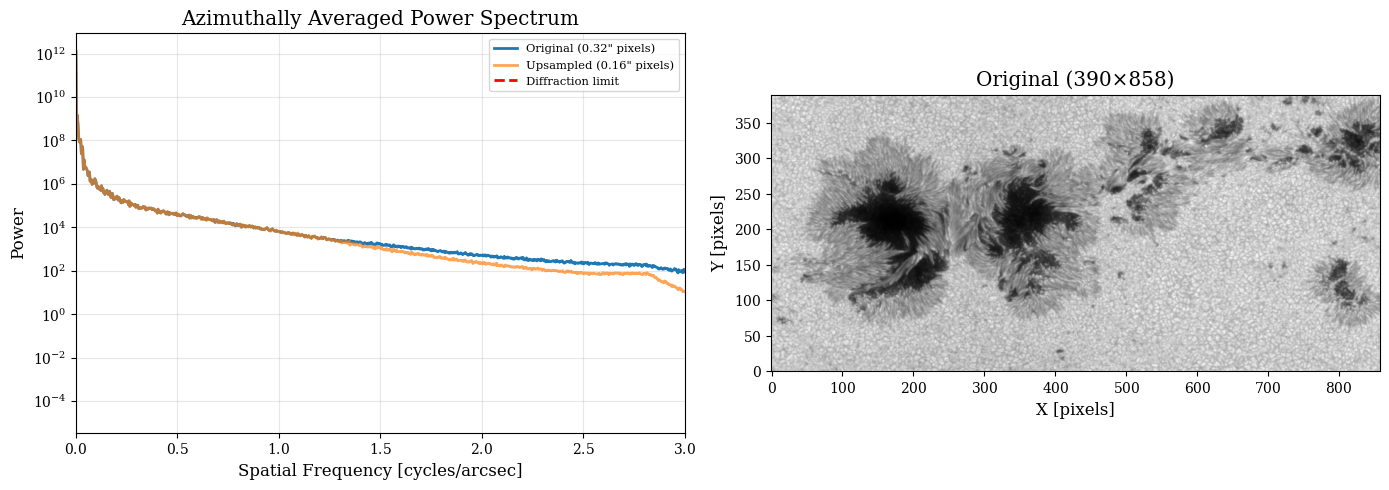

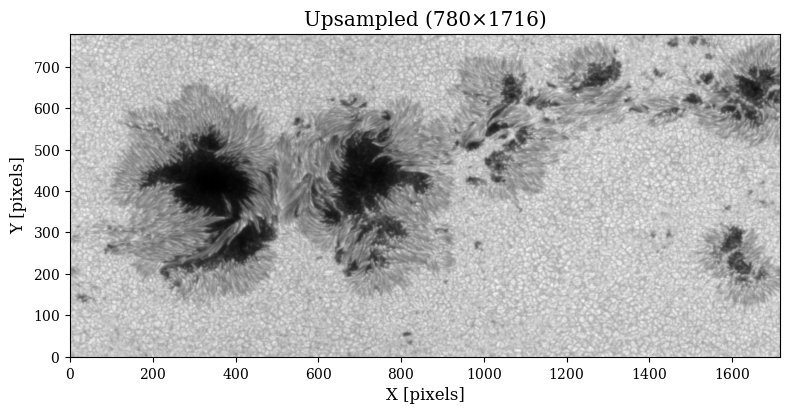

In [13]:
# Compute power spectra for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original image power spectrum
fc_orig = fftshift(fft2(np.pad(test_slice, [(test_slice.shape[0]//2, test_slice.shape[0]//2), 
                                              (test_slice.shape[1]//2, test_slice.shape[1]//2)], 
                                mode='reflect')))
power_orig = np.abs(fc_orig) ** 2
radial_orig = azimuthal_average(power_orig)

# Upsampled image power spectrum
fc_up = fftshift(fft2(np.pad(upsampled_test, [(upsampled_test.shape[0]//2, upsampled_test.shape[0]//2), 
                                                (upsampled_test.shape[1]//2, upsampled_test.shape[1]//2)], 
                              mode='reflect')))
power_up = np.abs(fc_up) ** 2
radial_up = azimuthal_average(power_up)

# Plot radial profiles
freq_orig = np.arange(len(radial_orig)) / (len(radial_orig) * pixel_scale_arcsec)
freq_up = np.arange(len(radial_up)) / (len(radial_up) * pixel_scale_arcsec / 2)

ax = axes[0]
ax.semilogy(freq_orig, radial_orig, label='Original (0.32" pixels)', linewidth=2)
ax.semilogy(freq_up, radial_up, label='Upsampled (0.16" pixels)', linewidth=2, alpha=0.7)
ax.axvline(1/thdifflim_arcsec, color='red', linestyle='--', linewidth=2, label='Diffraction limit')
ax.set_xlabel('Spatial Frequency [cycles/arcsec]')
ax.set_ylabel('Power')
ax.set_title('Azimuthally Averaged Power Spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 3)

# Plot images side by side
ax = axes[1]
ax.imshow(test_slice, cmap='gray', origin='lower')
ax.set_title(f'Original ({test_slice.shape[0]}×{test_slice.shape[1]})')
ax.set_xlabel('X [pixels]')
ax.set_ylabel('Y [pixels]')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(upsampled_test, cmap='gray', origin='lower')
ax.set_title(f'Upsampled ({upsampled_test.shape[0]}×{upsampled_test.shape[1]})')
ax.set_xlabel('X [pixels]')
ax.set_ylabel('Y [pixels]')
plt.tight_layout()
plt.show()

#### 4.2.6 Apply Upsampling to Full Stokes Cube

Now apply the upsampling to all wavelengths of Stokes I and V:

In [14]:
# Check if upsampling is needed
observation_mode = "fast"  # AR11967 is in fast mode
needs_upsampling = observation_mode == "fast"

if needs_upsampling:
    print("=" * 60)
    print("UPSAMPLING STOKES DATA FROM FAST MODE (0.32\") TO 0.16\"")
    print("=" * 60)
    print(f"Original dimensions: {obs_stokes['I'].shape}")
    
    # Initialize upsampled Stokes dictionaries
    ny_orig, nx_orig, nwl = obs_stokes["I"].shape
    upsampling_factor = 2
    ny_new = ny_orig * upsampling_factor
    nx_new = nx_orig * upsampling_factor
    
    upsampled_stokes = {
        "I": np.zeros((ny_new, nx_new, nwl), dtype=np.float32),
        "V": np.zeros((ny_new, nx_new, nwl), dtype=np.float32)
    }
    
    # Process each Stokes parameter
    for key in ["I", "V"]:
        print(f"\nUpsampling Stokes {key}...")
        for iw in range(nwl):
            if iw % 20 == 0:
                print(f"  Processing wavelength {iw+1}/{nwl}")
            
            upsampled_stokes[key][:, :, iw] = upsample_image_fft(
                obs_stokes[key][:, :, iw],
                upsampling_factor=upsampling_factor,
                q_number=q_number,
                seed=42 + iw  # Different seed per wavelength for independence
            )
    
    print(f"\nUpsampled dimensions: {upsampled_stokes['I'].shape}")
    print("=" * 60)
    
    # Update pixel scale and use upsampled data for deconvolution
    pixel_scale = 0.16  # arcsec/pixel after upsampling
    obs_stokes_for_deconv = upsampled_stokes
    
else:
    print("Normal mode - no upsampling needed")
    pixel_scale = 0.16
    obs_stokes_for_deconv = obs_stokes

UPSAMPLING STOKES DATA FROM FAST MODE (0.32") TO 0.16"
Original dimensions: (390, 858, 112)

Upsampling Stokes I...
  Processing wavelength 1/112
Estimated noise power: 77.628967
Noise std: 0.215248, Noise level: 360.648113
Estimated noise power: 77.549263
Noise std: 0.215025, Noise level: 360.652980
Estimated noise power: 77.329201
Noise std: 0.214637, Noise level: 360.278425
Estimated noise power: 77.417992
Noise std: 0.214567, Noise level: 360.811138


Estimated noise power: 77.116943
Noise std: 0.214565, Noise level: 359.410056
Estimated noise power: 77.187195
Noise std: 0.214928, Noise level: 359.131179
Estimated noise power: 77.224960
Noise std: 0.215219, Noise level: 358.821109
Estimated noise power: 77.167046
Noise std: 0.215427, Noise level: 358.205316
Estimated noise power: 77.063835
Noise std: 0.215724, Noise level: 357.234094
Estimated noise power: 77.019768
Noise std: 0.216025, Noise level: 356.531209
Estimated noise power: 77.024406
Noise std: 0.216369, Noise level: 355.986064
Estimated noise power: 76.838203
Noise std: 0.216812, Noise level: 354.399979
Estimated noise power: 76.592186
Noise std: 0.217555, Noise level: 352.059540
Estimated noise power: 76.366585
Noise std: 0.218356, Noise level: 349.734463
Estimated noise power: 75.966782
Noise std: 0.218387, Noise level: 347.853404
Estimated noise power: 75.527763
Noise std: 0.218519, Noise level: 345.635147
Estimated noise power: 74.815613
Noise std: 0.218638, Noise leve

**Note:** After upsampling, the spatial dimensions are doubled and the effective pixel scale is 0.16" × 0.16", matching the PSF resolution. All subsequent processing operates on these upsampled dimensions.

In [15]:
# Load and normalize PSF
with fits.open(psf_path) as hdul:
    psf = hdul[0].data
psf = np.ascontiguousarray(psf, dtype=np.float32)
psf = psf / np.sum(psf)

print(f"PSF shape: {psf.shape}")
print(f"PSF sum: {np.sum(psf):.6f} (should be 1.0)")

# Wiener deconvolution helper
def wiener_deconv(image: np.ndarray, psf_kernel: np.ndarray, k: float) -> np.ndarray:
    """Apply Wiener deconvolution to remove PSF blurring.
    
    Parameters
    ----------
    image : np.ndarray
        Input image
    psf_kernel : np.ndarray
        Point spread function
    k : float
        Noise regularization parameter
        
    Returns
    -------
    np.ndarray
        Deconvolved image
    """
    psf_padded = np.zeros_like(image)
    pc = (psf_kernel.shape[0] // 2, psf_kernel.shape[1] // 2)
    ic = (image.shape[0] // 2, image.shape[1] // 2)
    y0, y1 = ic[0] - pc[0], ic[0] - pc[0] + psf_kernel.shape[0]
    x0, x1 = ic[1] - pc[1], ic[1] - pc[1] + psf_kernel.shape[1]
    psf_padded[y0:y1, x0:x1] = psf_kernel
    psf_padded = fftshift(psf_padded)
    img_fft = fft2(image)
    psf_fft = fft2(psf_padded)
    wiener = np.conj(psf_fft) / (np.abs(psf_fft) ** 2 + k)
    return np.real(ifft2(img_fft * wiener))

# Apply deconvolution using the properly scaled data
noise_level = 0.01
ny, nx, n_wl = obs_stokes_for_deconv["I"].shape

print(f"\nApplying Wiener deconvolution to {ny}×{nx}×{n_wl} cube...")
deconvolved_stokes = {key: np.zeros((ny, nx, n_wl), dtype=np.float32) for key in obs_stokes_for_deconv.keys()}

for key in obs_stokes_for_deconv.keys():
    print(f"Deconvolving Stokes {key}...")
    for iw in range(n_wl):
        if iw % 20 == 0:
            print(f"  Wavelength {iw+1}/{n_wl}")
        deconvolved_stokes[key][:, :, iw] = wiener_deconv(obs_stokes_for_deconv[key][:, :, iw], psf, noise_level)
    print(f"  Completed: {deconvolved_stokes[key].shape}")

PSF shape: (61, 61)
PSF sum: 1.000000 (should be 1.0)

Applying Wiener deconvolution to 780×1716×112 cube...
Deconvolving Stokes I...
  Wavelength 1/112


  Wavelength 21/112
  Wavelength 41/112
  Wavelength 61/112
  Wavelength 81/112
  Wavelength 101/112
  Completed: (780, 1716, 112)
Deconvolving Stokes V...
  Wavelength 1/112
  Wavelength 21/112
  Wavelength 41/112
  Wavelength 61/112
  Wavelength 81/112
  Wavelength 101/112
  Completed: (780, 1716, 112)


In [16]:
if needs_upsampling:
    print("Updating sample pixel coordinates for upsampled grid...")
    sample_pixels_upsampled = {}
    for key, pixel_info in sample_pixels.items():
        sample_pixels_upsampled[key] = {
            'y': pixel_info['y'] * upsampling_factor,
            'x': pixel_info['x'] * upsampling_factor,
            'label': pixel_info['label']
        }
    # Use upsampled coordinates for plotting
    sample_pixels_for_plots = sample_pixels_upsampled
    print(f"Example: {list(sample_pixels.keys())[0]} moved from "
          f"({sample_pixels[list(sample_pixels.keys())[0]]['x']:.1f}, "
          f"{sample_pixels[list(sample_pixels.keys())[0]]['y']:.1f}) to "
          f"({sample_pixels_upsampled[list(sample_pixels.keys())[0]]['x']:.1f}, "
          f"({sample_pixels_upsampled[list(sample_pixels.keys())[0]]['y']:.1f})")
else:
    sample_pixels_for_plots = sample_pixels

Updating sample pixel coordinates for upsampled grid...
Example: max_continuum moved from (554.0, 377.0) to (1108.0, (754.0)


In [17]:
def plot_modest_stokes_profiles(
    wl: u.Quantity | np.ndarray,
    stokes_data: dict[str, np.ndarray],
    sample_pixels: dict[str, dict[str, float]],
    sample_wavelength_idx: int,
    stokes_labels: tuple[str, str] = ("Stokes I", "Stokes V"),
    title: str = "Stokes Profiles",
    save_path: Path | str | None = None,
) -> None:
    """Plot Stokes profiles at sample pixels."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i, (_, pixel_info) in enumerate(sample_pixels.items()):
        sample_x, sample_y = int(pixel_info["x"]), int(pixel_info["y"])
        profiles = [stokes_data["I"][sample_y, sample_x, :], stokes_data["V"][sample_y, sample_x, :]]
        for row, (profile, label) in enumerate(zip(profiles, stokes_labels)):
            ax = axes[row, i]
            ax.plot(wl, profile, "b-", linewidth=1.5)
            if not np.isnan(profile[sample_wavelength_idx]):
                ax.plot(wl[sample_wavelength_idx], profile[sample_wavelength_idx], "ro", markersize=6)
            ax.set_title(f"{label} - {pixel_info['label']}", fontsize=10)
            ax.set_ylabel("Intensity" if row == 0 else "Polarization")
            ax.set_xlabel("Wavelength [Angstrom]")
            ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)


def plot_modest_stokes_images(
    stokes_dict: dict[str, np.ndarray],
    sample_pixels: dict[str, dict[str, float]],
    wl: u.Quantity | np.ndarray,
    sample_wavelength_idx: int,
    stokes_labels: tuple[str, str] = ("Stokes I", "Stokes V"),
    title: str = "Stokes Parameters",
    save_path: Path | str | None = None,
) -> None:
    """Plot Stokes images (I, V) at a given wavelength with sample pixels marked."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    images = [stokes_dict["I"][:, :, sample_wavelength_idx], stokes_dict["V"][:, :, sample_wavelength_idx]]
    for col, (img, label) in enumerate(zip(images, stokes_labels)):
        ax = axes[col]

        valid = img[~np.isnan(img)]
        if valid.size > 0:
            if col == 0:
                vmin, vmax = np.quantile(valid, [0.05, 0.95])
            else:
                q1, q99 = np.quantile(valid, [0.01, 0.99])
                abs_max = np.max(np.abs([q1, q99]))
                vmin, vmax = -abs_max, abs_max
        else:
            vmin, vmax = (0, 1) if col == 0 else (-1, 1)

        im = ax.imshow(img, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=12)
        ax.set_ylabel("Y [pixels]")
        ax.set_xlabel("X [pixels]")

        colors = ["red", "blue", "green", "orange"]
        markers = ["x", "o", "s", "^"]
        for i, (_, p_info) in enumerate(sample_pixels.items()):
            ax.plot(p_info["x"], p_info["y"], markers[i], color=colors[i], markersize=10, markeredgewidth=2,
                    label=p_info["label"])

        if col == 0:
            ax.legend(loc="upper right", fontsize=8)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im, cax=cax)

    wl_val = wl[sample_wavelength_idx].value if hasattr(wl, "unit") else wl[sample_wavelength_idx]
    plt.suptitle(f"{title} at lambda = {wl_val:.3f} Angstrom", fontsize=14)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

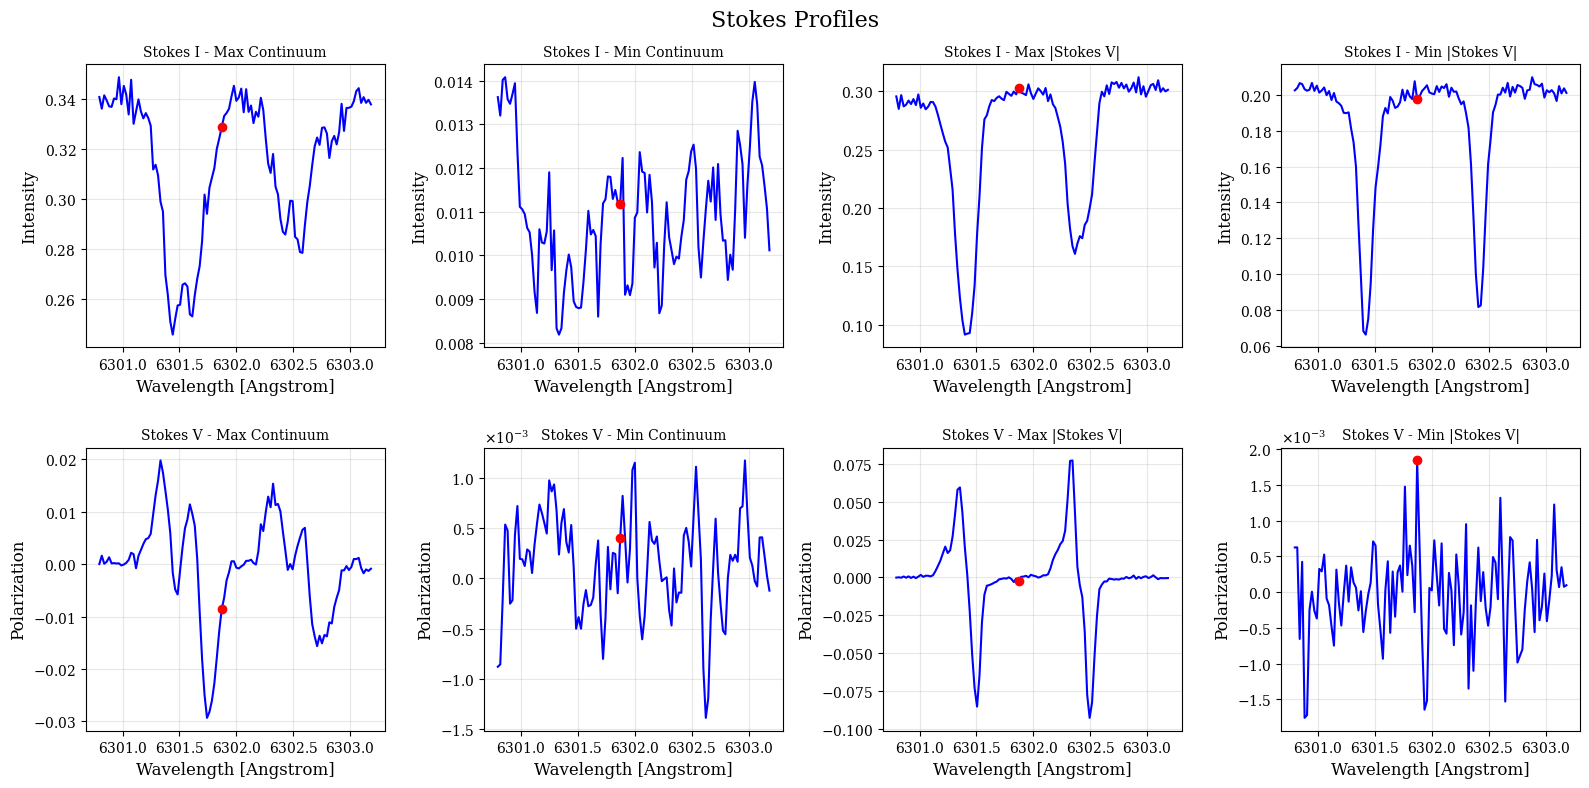

In [18]:
swi_obs = 50  # Example index for marking
plot_modest_stokes_profiles(wl_obs, deconvolved_stokes, sample_pixels_for_plots, swi_obs)

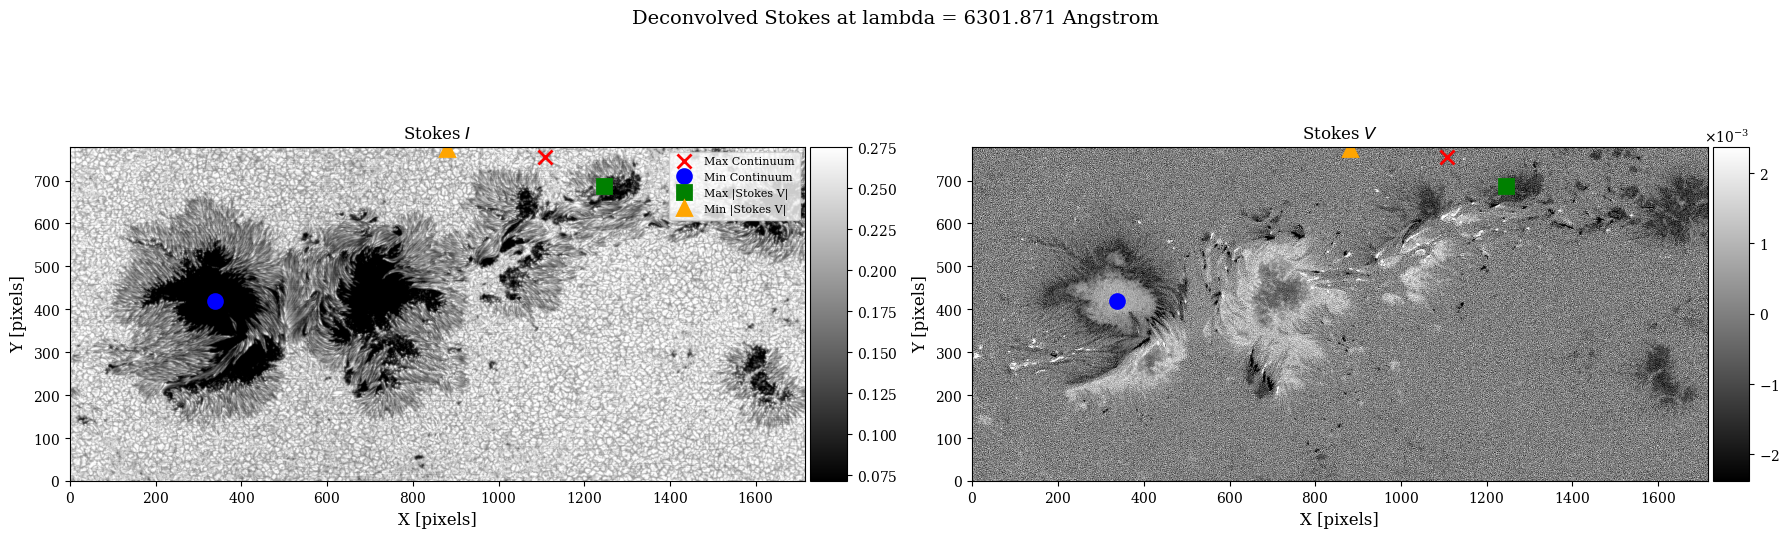

In [19]:
plot_modest_stokes_images(stokes_dict = deconvolved_stokes,
                                    sample_pixels = sample_pixels_for_plots,
                                    wl = wl_obs,
                                    sample_wavelength_idx = swi_obs,
                                    stokes_labels = ['Stokes $I$', 'Stokes $V$'],
                                    title="Deconvolved Stokes")

### 4.6 Spectral Smoothing

Additionally we will perform a rolling average window over the profile to smooth it.

In [20]:
from scipy.ndimage import uniform_filter1d

# Apply rolling average window over wavelength axis (axis 2) for smoothing
window_size = 7
smoothed_stokes = {}

for key in deconvolved_stokes.keys():
    smoothed_stokes[key] = uniform_filter1d(deconvolved_stokes[key], size=window_size, axis=2)
    print(f"smoothed_stokes {key}:", smoothed_stokes[key].shape)

smoothed_stokes I: (780, 1716, 112)


smoothed_stokes V: (780, 1716, 112)


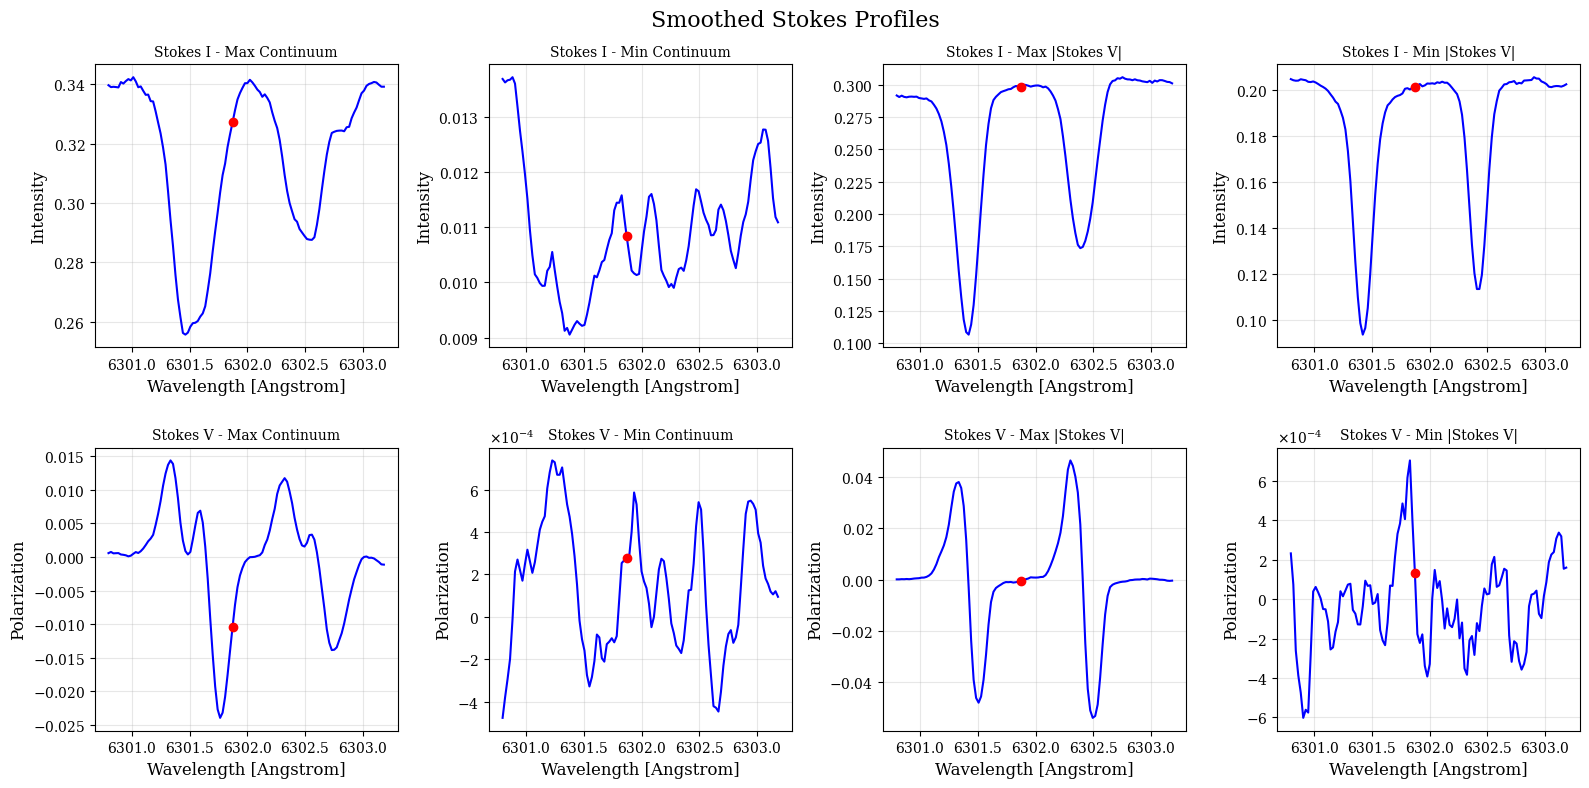

In [21]:
plot_modest_stokes_profiles(
    wl = wl_obs,
    stokes_data = smoothed_stokes,
    sample_pixels = sample_pixels_for_plots,
    sample_wavelength_idx = swi_obs,
    stokes_labels = ("Stokes I", "Stokes V"),
    title = "Smoothed Stokes Profiles",
)

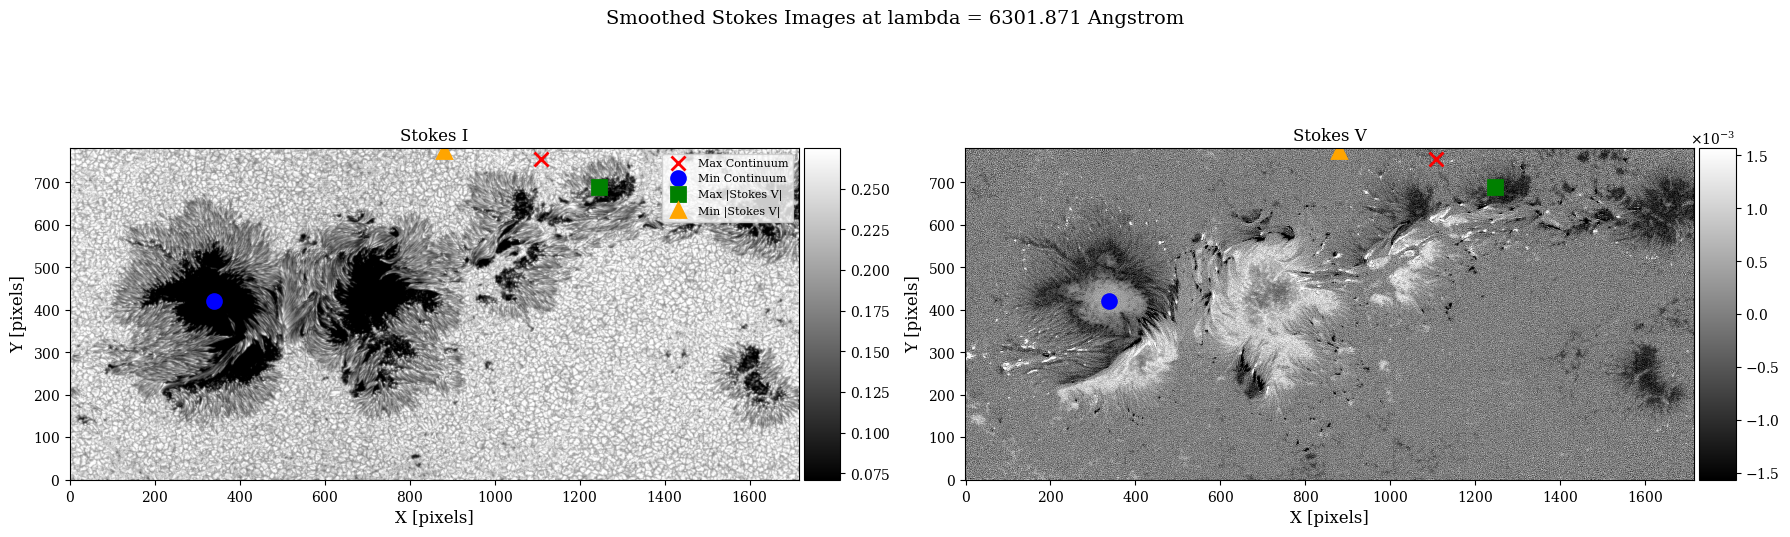

In [22]:
plot_modest_stokes_images(
    stokes_dict = smoothed_stokes,
    sample_pixels = sample_pixels_for_plots,
    wl = wl_obs,
    sample_wavelength_idx = swi_obs,
    stokes_labels = ("Stokes I", "Stokes V"),
    title = "Smoothed Stokes Images",
    save_path = None
)

## 6. Load Inverted Profiles (I, V)
We read the inverted profile cube and keep I and V channels only.

In [23]:
with fits.open(modest_dir / "inverted_profs.1.fits") as hdul:
    inv_cube_full = hdul[0].data  # (ny, nx, 4, nwl_inv)
# Keep I (0) and V (1)
inverted_profs = {}
inverted_profs["I"] = inv_cube_full[:, :, 0, :]
inverted_profs["V"] = inv_cube_full[:, :, 1, :]
print("inverted_profs (I,V):", {key: val.shape for key, val in inverted_profs.items()})

inverted_profs (I,V): {'I': (390, 858, 250), 'V': (390, 858, 250)}


IndexError: index 754 is out of bounds for axis 0 with size 390

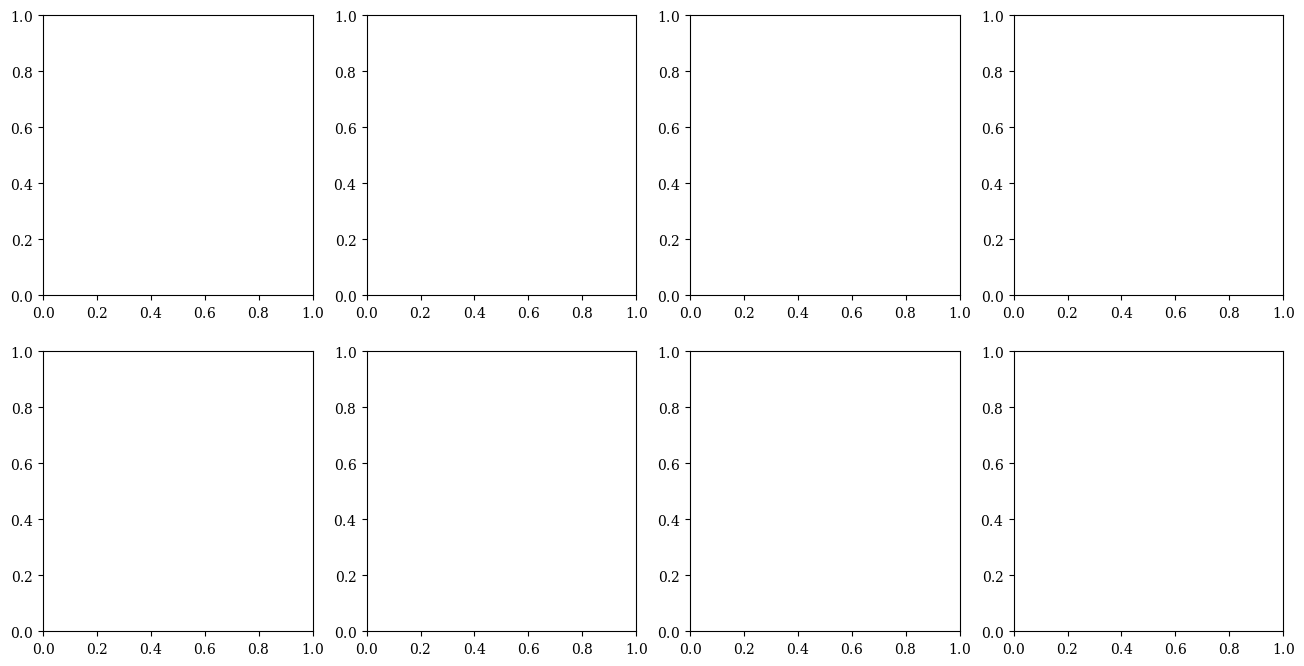

In [24]:
swi_inv = 125
plot_modest_stokes_profiles(
    stokes_data = inverted_profs,
    sample_pixels = sample_pixels_for_plots,
    wl = wl_obs,
    sample_wavelength_idx = swi_inv,
    stokes_labels = ("Stokes I", "Stokes V"),
    title = "Inverted Stokes Profiles",
    save_path = None,
)

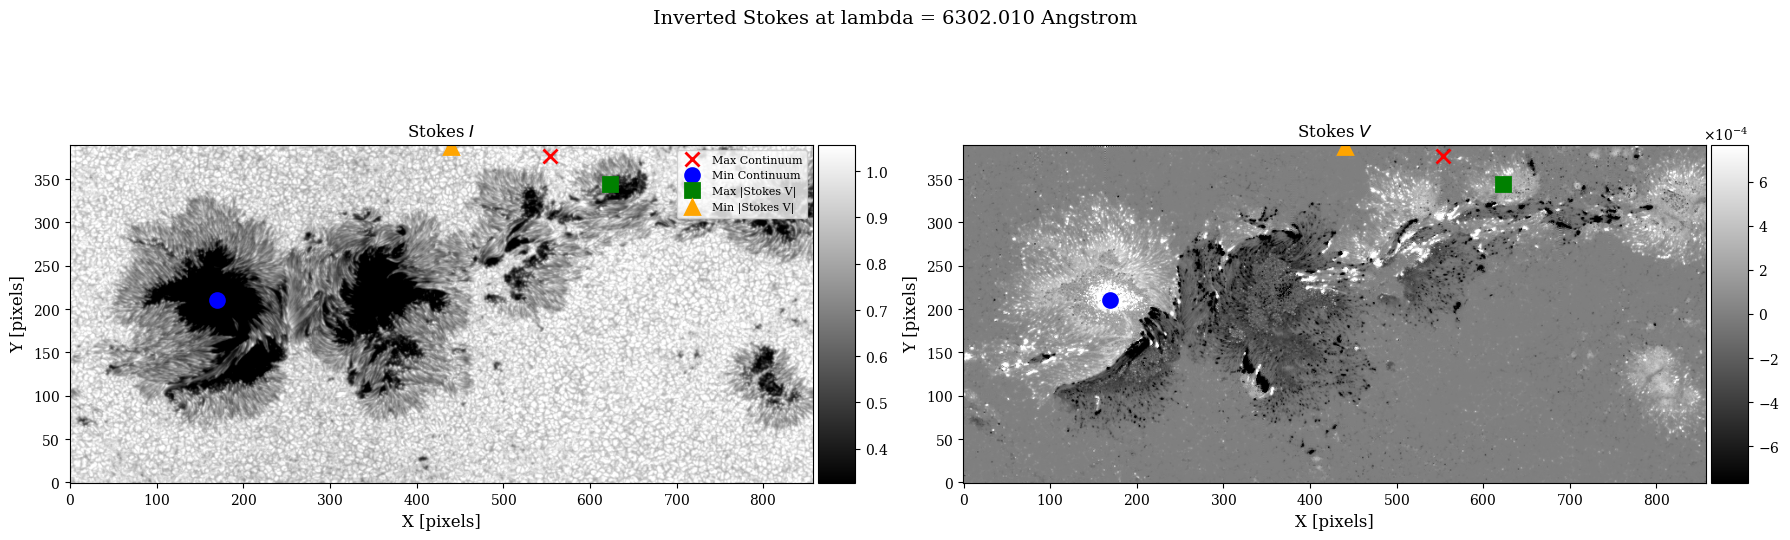

In [ ]:
plot_modest_stokes_images(stokes_dict = inverted_profs,
                            sample_pixels = sample_pixels,
                            wl = wl_inv,
                            sample_wavelength_idx = swi_inv,
                            stokes_labels = ['Stokes $I$', 'Stokes $V$'],
                            title="Inverted Stokes",
                            save_path=None)

## 7. Load Inverted Atmosphere (SPINOR 2D)
The SPINOR 2D output contains multiple parameters indexed in the first axis. We reconstruct convenient maps at $\log\tau \in \{-2.0, -0.8, 0.0\}$ for temperature, velocity, and line-of-sight magnetic field $B_{los} = |B|\cos(\gamma)$ using SPINOR indices used in the project.

In [ ]:
with fits.open(modest_dir / "inverted_atmos.fits") as hdul:
    inverted_atmos = hdul[0].data  # (n_params, ny, nx)
print("inverted_atmos:", inverted_atmos.shape)

tau_values = [-2.0, -0.8, 0.0]
temp_indices = [8, 6, 7]
vel_indices = [20, 18, 19]
mag_field_indices = [11, 9, 10]
gamma_indices = [14, 12, 13]
spinor_atm = {"T": {}, "Vlos": {}, "Blos": {}}
for i, tau in enumerate(tau_values):
    spinor_atm["T"][tau] = inverted_atmos[temp_indices[i]]
    spinor_atm["Vlos"][tau] = inverted_atmos[vel_indices[i]]
    b_field = inverted_atmos[mag_field_indices[i]]
    gamma_deg = inverted_atmos[gamma_indices[i]]
    gamma_rad = np.deg2rad(gamma_deg)
    blos = b_field * np.cos(gamma_rad)
    spinor_atm["Blos"][tau] = blos

inverted_atmos: (23, 390, 858)


In [ ]:
def plot_modest_spinor_atmos(spinor_atm: dict, sample_pixels: dict, modest_images_dir: str = None) -> None:
    """Plot SPINOR atmospheric parameters for the full scene with masking applied."""
    # Use the full scene atmospheric dictionary that includes masking
    tau_values = [-2.0, -0.8, 0.0]
    
    # Temperature
    temp_data = [spinor_atm["T"][tau] for tau in tau_values]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    temp_labels = ['log τ = -2.0', 'log τ = -0.8', 'log τ = 0.0']
    for i, (ax, label) in enumerate(zip(axes, temp_labels)):
        # Calculate quantiles only from non-NaN values for proper scaling
        valid_data = temp_data[i][~np.isnan(temp_data[i])]
        if len(valid_data) > 0:
            vmin = np.quantile(valid_data, 0.05)
            vmax = np.quantile(valid_data, 0.95)
        else:
            vmin, vmax = 0, 1
        im = ax.imshow(temp_data[i], cmap='hot', origin='lower', vmin=vmin, vmax=vmax)
        ax.set_title(label)
        ax.set_xlabel('X [pixels]')
        ax.set_ylabel('Y [pixels]')
        for j, (key, pixel_info) in enumerate(sample_pixels.items()):
            colors = ['cyan', 'magenta', 'green', 'red']
            ax.plot(pixel_info['x'], pixel_info['y'], 'x', color=colors[j], markersize=8, markeredgewidth=2)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label('[K]')
    plt.suptitle('SPINOR 2D Inverted Temperature - Full Scene (Masked)', fontsize=16)
    plt.tight_layout()
    if modest_images_dir:
        save_dir = Path(modest_images_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(modest_images_dir / "spinor_temperature.png", dpi=300, bbox_inches='tight')
    else:
        plt.show()
    plt.close(fig)
    
    # Velocity
    vel_data = [spinor_atm["Vlos"][tau] for tau in tau_values]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    vel_labels = ['log τ = -2.0', 'log τ = -0.8', 'log τ = 0.0']
    for i, (ax, label) in enumerate(zip(axes, vel_labels)):
        # Calculate quantiles only from non-NaN values for proper scaling
        valid_data = vel_data[i][~np.isnan(vel_data[i])]
        if len(valid_data) > 0:
            vmin = np.quantile(valid_data, 0.01)
            vmax = np.quantile(valid_data, 0.99)
            if np.abs(vmin) > np.abs(vmax):
                vmax = np.abs(vmin)
            else:
                vmin = -np.abs(vmax)
        else:
            vmin, vmax = -1, 1
        im = ax.imshow(vel_data[i], cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
        ax.set_title(label)
        ax.set_xlabel('X [pixels]')
        ax.set_ylabel('Y [pixels]')
        for j, (key, pixel_info) in enumerate(sample_pixels.items()):
            colors = ['cyan', 'magenta', 'green', 'red']
            ax.plot(pixel_info['x'], pixel_info['y'], 'x', color=colors[j], markersize=8, markeredgewidth=2)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label('[Km/s]')
    plt.suptitle(r'SPINOR 2D Inverted $v_\text{LOS}$ - Full Scene (Masked)', fontsize=16)
    plt.tight_layout()
    if modest_images_dir:
        save_dir = Path(modest_images_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(modest_images_dir / "spinor_velocity.png", dpi=300, bbox_inches='tight')
    else:
        plt.show()
    plt.close(fig)
    
    # B_LOS
    blos_data = [spinor_atm["Blos"][tau] for tau in tau_values]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    blos_labels = ['log τ = -2.0', 'log τ = -0.8', 'log τ = 0.0']
    for i, (ax, label) in enumerate(zip(axes, blos_labels)):
        # Calculate quantiles only from non-NaN values for proper scaling
        valid_data = blos_data[i][~np.isnan(blos_data[i])]
        if len(valid_data) > 0:
            vmin = np.quantile(valid_data, 0.01)
            vmax = np.quantile(valid_data, 0.99)
            if np.abs(vmin) > np.abs(vmax): 
                vmax = np.abs(vmin)
            else: 
                vmin = -np.abs(vmax)
        else:
            vmin, vmax = -1, 1
        im = ax.imshow(blos_data[i], cmap='PiYG', origin='lower', vmin=vmin, vmax=vmax)
        ax.set_title(label)
        ax.set_xlabel('X [pixels]')
        ax.set_ylabel('Y [pixels]')
        for j, (key, pixel_info) in enumerate(sample_pixels.items()):
            colors = ['cyan', 'magenta', 'green', 'red']
            ax.plot(pixel_info['x'], pixel_info['y'], 'x', color=colors[j], markersize=8, markeredgewidth=2)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label('[G]')
    plt.suptitle(r'SPINOR 2D Inverted $B_{\text{LOS}}$ - Full Scene (Masked)', fontsize=16)
    plt.tight_layout()
    if modest_images_dir:
        save_dir = Path(modest_images_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(modest_images_dir / "spinor_blos.png", dpi=300, bbox_inches='tight')
    else:
        plt.show()
    plt.close(fig)

In [ ]:
plot_modest_spinor_atmos(spinor_atm, sample_pixels, modest_images_dir=None)

NameError: name 'plot_modest_spinor_atmos' is not defined

## 8. Circular Polarization and Mask (Optional)
We compute mean |V|/I over wavelength and create a boolean mask using a threshold. The mask is applied across all products by setting masked pixels to NaN.

In [ ]:
# Compute circular polarization map from observed Stokes (I,V)
epsilon = 1e-10
I_safe = np.maximum(obs_stokes["I"], epsilon)
circ_pol = np.mean(np.abs(obs_stokes["V"]) / I_safe, axis=-1)

# Create mask: True = keep, False = masked
mask = circ_pol <= circular_polarization_threshold

# Apply mask across datasets by setting masked pixels to NaN
continuum_masked = continuum.copy()
continuum_masked[~mask] = np.nan

obs_stokes_masked = {key: val.copy() for key, val in obs_stokes.items()}
for key in obs_stokes_masked.keys():
    obs_stokes_masked[key][~mask] = np.nan

smoothed_stokes_masked = {key: val.copy() for key, val in smoothed_stokes.items()}
for key in smoothed_stokes_masked.keys():
    smoothed_stokes_masked[key][~mask] = np.nan
    
inverted_profs_masked = {key: val.copy() for key, val in inverted_profs.items()}
for key in inverted_profs_masked.keys():
    inverted_profs_masked[key][~mask] = np.nan

spinor_atmos_masked = {}
for key in spinor_atm.keys():
    spinor_atmos_masked[key] = {}
    for tau in spinor_atm[key].keys():
        spinor_atmos_masked[key][tau] = spinor_atm[key][tau].copy()
for key in spinor_atmos_masked.keys():
    for tau in spinor_atmos_masked[key].keys():
        spinor_atmos_masked[key][tau][~mask] = np.nan
        
print("mask True count (kept):", np.sum(mask), "of", mask.size)

mask True count (kept): 177691 of 334620


In [ ]:
plot_modest_continuum(continuum_masked, sample_pixels, x_center_fov_pixel, y_center_fov_pixel,
                                   x_disk_center, y_disk_center, arrow_start_x, arrow_start_y,
                                   arrow_dx, arrow_dy)

NameError: name 'continuum_masked' is not defined

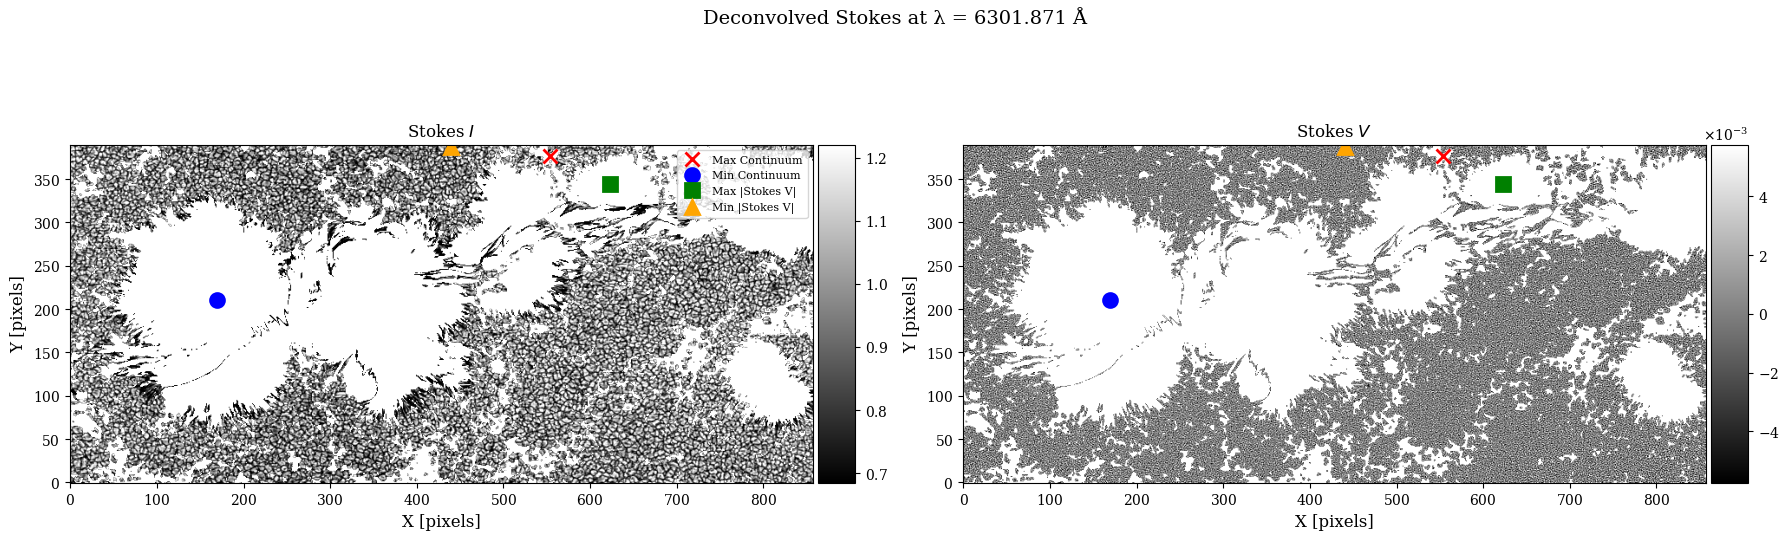

In [ ]:
plot_modest_stokes_images(stokes_dict = smoothed_stokes_masked,
                                    sample_pixels = sample_pixels_for_plots,
                                    wl = wl_obs,
                                    sample_wavelength_idx = swi_obs,
                                    stokes_labels = ['Stokes $I$', 'Stokes $V$'],
                                    title="Deconvolved Stokes",
                                    modest_images_dir=None)

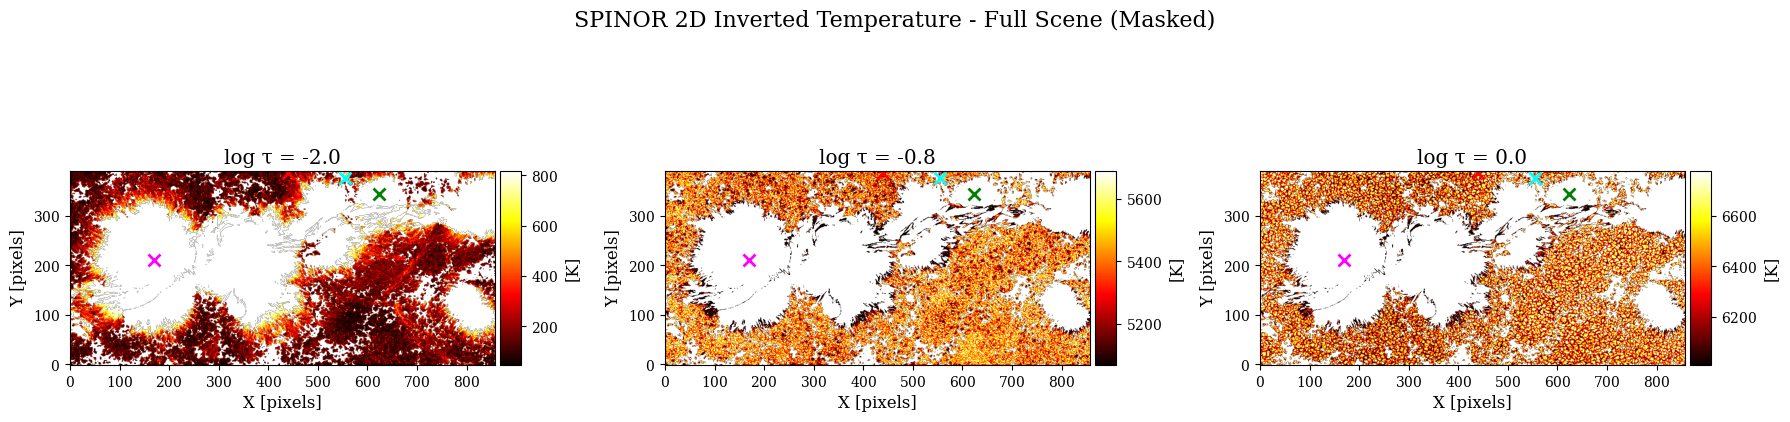

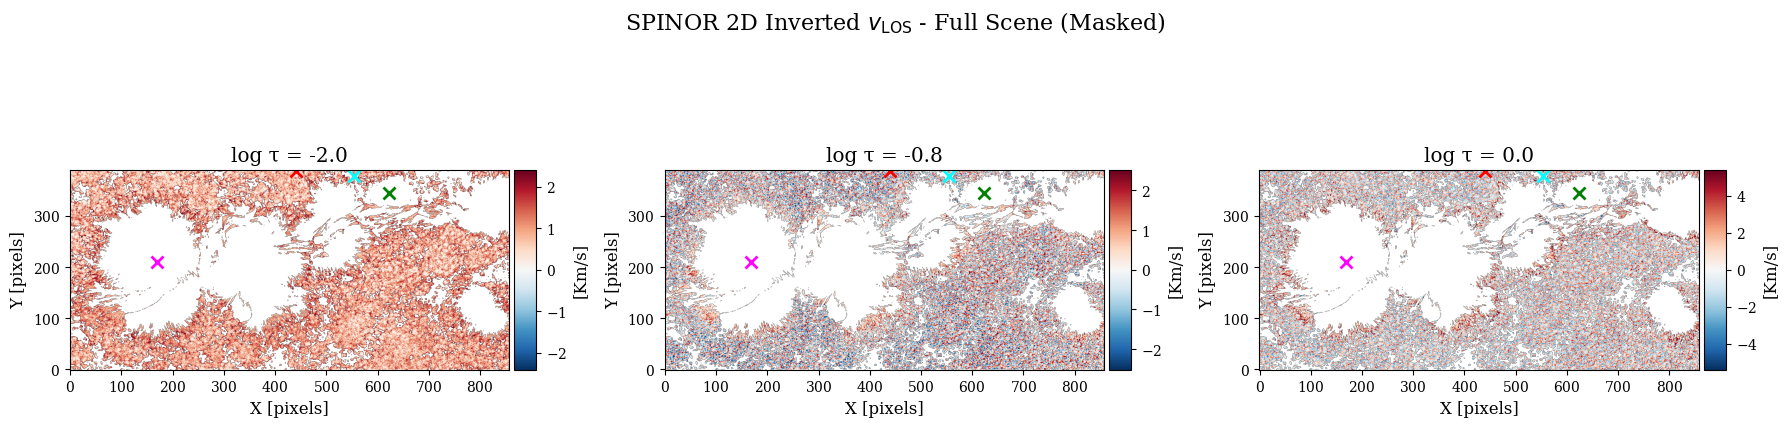

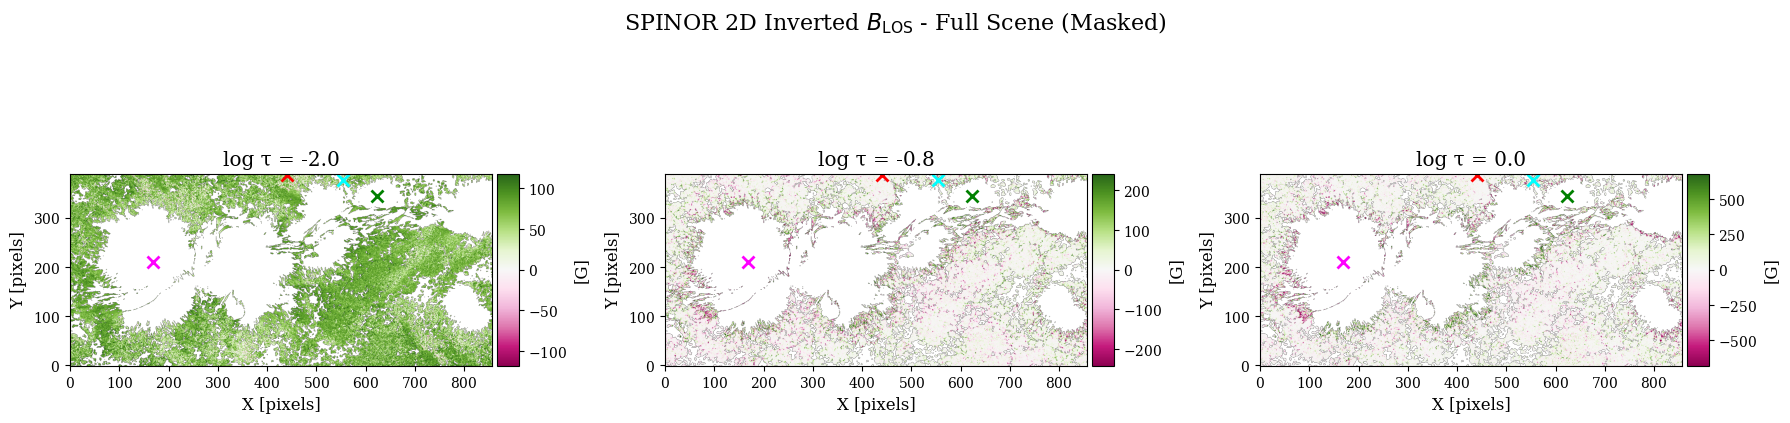

In [ ]:
plot_modest_spinor_atmos(spinor_atmos_masked, sample_pixels, modest_images_dir=None)